#### Импорты

In [ ]:
!pip install transformers peft accelerate datasets adjustText

In [ ]:
from collections import Counter, defaultdict

In [ ]:
import os
import re
import torch
import numpy as np
import pandas as pd
import csv
from collections import Counter
from transformers import AutoTokenizer, AutoModel
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from adjustText import adjust_text

from sentence_transformers import SentenceTransformer, losses, InputExample
from sentence_transformers.models import Transformer, Pooling
from torch.utils.data import DataLoader

from nltk.corpus import stopwords
import nltk
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

from nltk.tokenize import sent_tokenize

from datasets import Dataset
from google.colab import drive
import pickle

In [ ]:
lemmatizer = WordNetLemmatizer()

### Загрузка и чтение текста

Обработка txt

In [ ]:
def load_and_clean_text(filepath):
    """Загружает текст и убирает маркеры глав."""
    with open(filepath, encoding="utf-8") as f:
        text = f.read()

    # Убирает "chapter" и его вариации
    text = re.sub(r'^\s*chapter\b.*$', '', text, flags=re.IGNORECASE | re.MULTILINE)
    text = text.replace("�", "")
    text = re.sub(r"\s*\n\s*", " ", text)
    return text

In [ ]:
def split_into_sentences(text):
    sentences = sent_tokenize(text)
    return [s.strip() for s in sentences if len(s.strip()) > 10]

In [ ]:
rebecca_text = load_and_clean_text("")  # вставляем ссылку на txt
rebecca_sentences = split_into_sentences(rebecca_text)

Сохранение обработанного текста в датафрейм

In [ ]:
reb_sent = pd.DataFrame({"sentence": rebecca_sentences})

In [ ]:
''' Cохранить датафрейм в формате csv '''
reb_sent.to_csv('/rebecca_sentences_mbert.csv', sep='\t', index=False)

Загрузка подготовленного датафрейма

In [ ]:
''' Чтение сохранненого датафрейма'''
reb_sent = pd.read_csv("/rebecca_sentences_mbert.csv")

In [ ]:
rebecca_sentences = reb_sent['sentence'].to_list()

### Загрузка модели


In [ ]:
MODEL_NAME = "answerdotai/ModernBERT-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("device:", device)
print("hidden_size:", model.config.hidden_size)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
head.norm.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


device: cuda
hidden_size: 768


## Основной код

### Функции

In [ ]:
def get_target_forms(word):
    """
    Возвращает допустимые словоформы целевого слова.
    Для концепта love объединяем формы в один концептуальный класс.
    """
    if word.lower() == "love":
        return {"love", "loves", "loved"}
    return {word.lower()}

In [ ]:
def get_word_pattern(word):
    """
    Regex-паттерн для поиска слова в предложении.
    Для love ищем только словоформы love/loves/loved,
    но не lovely, beloved и т.д.
    """
    if word.lower() == "love":
        return r"\blove(?:s|d)?\b"
    return rf"\b{re.escape(word)}\b"

In [ ]:
def extract_word_contexts(concept_word, sentences, max_contexts=500):
    """
    Находит все предложения, содержащие целевое слово или его словоформы.
    """
    pattern = get_word_pattern(concept_word)
    contexts = []

    for idx, sentence in enumerate(sentences):
        if re.search(pattern, sentence, re.IGNORECASE):
            contexts.append((sentence, idx))
            if len(contexts) >= max_contexts:
                break

    return contexts

In [ ]:
def get_word_vector_in_context(word, sentence, tokenizer, model, device, pattern=None, debug=False):
    if pattern is None:
        pattern = r'\b' + re.escape(word) + r'\b'

    # Находим символьный span совпадения в предложении
    match = re.search(pattern, sentence, re.IGNORECASE)
    if not match:
        return None

    char_start, char_end = match.start(), match.end()

    encoding = tokenizer(
        sentence,
        return_tensors='pt',
        return_offsets_mapping=True,
        truncation=True,
        max_length=512
    )

    offset_mapping = encoding['offset_mapping'][0].tolist()

    # Ищем токены, чьи offset'ы ПЕРЕКРЫВАЮТСЯ с char_start..char_end
    target_indices = [
        i for i, (s, e) in enumerate(offset_mapping)
        if e > char_start and s < char_end and e > s  # перекрытие, не пустой токен
    ]

    if debug:
        print(f"Match: '{match.group()}' [{char_start}:{char_end}]")
        print(f"Target token indices: {target_indices}")

    if not target_indices:
        return None

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    hidden_states = outputs.last_hidden_state[0]  # [seq_len, hidden_dim]

    # Усредняем по всем subword-токенам слова
    token_vecs = hidden_states[target_indices]
    return token_vecs.mean(dim=0).cpu().numpy()

In [ ]:
def build_contextual_embeddings(concept_word, sentences, tokenizer, model, device, max_contexts=500, debug=False):
    """
    Главная функция для построения контекстуальных эмбеддингов концепта.

    Шаги:
    1. Находит предложения с целевым словом / словоформами.
    2. Извлекает вектор целевого слова в каждом контексте.
    3. Собирает матрицу всех контекстных векторов.
    4. Усредняет их => итоговый вектор концепта в романе.
    """
    print(f"\n🔍 Поиск контекстов для '{concept_word}'...")
    contexts = extract_word_contexts(concept_word, sentences, max_contexts)

    print(f"✓ Найдено {len(contexts)} контекстов")

    if len(contexts) == 0:
        print(f"❌ Слово '{concept_word}' не найдено в тексте!")
        return None, [], None

    print(f"📊 Генерация эмбеддингов в контексте...")

    word_vectors = []
    valid_contexts = []

    for i, (sentence, sent_idx) in enumerate(contexts):
        if i % max(1, len(contexts) // 10) == 0:
            print(f"  {i}/{len(contexts)}", end="\r")

        try:
            vec = get_word_vector_in_context(
                concept_word,
                sentence,
                tokenizer,
                model,
                device,
                debug=(debug and i < 5)
            )

            if vec is not None:
                word_vectors.append(vec)
                valid_contexts.append((sentence, sent_idx))
            elif debug and i < 10:
                print(f"\n[NONE] {sentence}")

        except Exception as e:
            if debug:
                print(f"\n[ERROR] {e} :: {sentence}")
            continue

    if len(word_vectors) == 0:
        print(f"❌ Не удалось извлечь векторы!")
        return None, [], None

    word_vectors = np.array(word_vectors)

    # Итоговый усредненный вектор концепта:
    # для love это среднее по всем найденным реализациям love/loves/loved
    avg_vector = word_vectors.mean(axis=0)

    # Нормализация
    avg_vector = avg_vector / (np.linalg.norm(avg_vector) + 1e-9)

    print(f"✓ Обработано {len(word_vectors)} контекстов\n")

    return word_vectors, valid_contexts, avg_vector


* Версия 1: построение словаря контекстных эмбеддингов по топ-200 слов

In [ ]:
def build_contextual_vocab_embeddings_top_w(
    concept_word,
    all_sentences,
    tokenizer,
    model,
    device,
    top_k_words=200,
    max_contexts_per_word=50
):
    """
    Строит словарь контекстных эмбеддингов слов из всего текста романа.

    Логика:
    1. Собираем все слова романа.
    2. Убираем стоп-слова, короткие слова и само concept_word.
    3. Берем top_k_words самых частотных слов.
    4. Для каждого слова усредняем его контекстные эмбеддинги.
    """
    stopwords_set = set(stopwords.words("english"))

    print("🔤 Построение контекстного словаря из ВСЕГО текста...")

    all_words = Counter()
    for sentence in all_sentences:
        words = re.findall(r"\b[a-z]+(?:'[a-z]+)?\b", sentence.lower())
        for w in words:
            if w not in stopwords_set and len(w) > 2 and w != concept_word.lower():
                all_words[w] += 1

    top_words = [w for w, _ in all_words.most_common(top_k_words)]

    print(f"✓ Выбрано {len(top_words)} слов для анализа (из {len(all_words)} уникальных)")

    word2vec_contextual = {}

    print("📊 Генерация контекстных эмбеддингов для слов...")

    for word_idx, word in enumerate(top_words):
        if word_idx % max(1, len(top_words) // 10) == 0:
            print(f"  {word_idx}/{len(top_words)}", end="\r")

        pattern = get_word_pattern(word)
        word_sentences = [
            s for s in all_sentences
            if re.search(pattern, s, re.IGNORECASE)
        ]

        vectors_for_word = []
        for sent in word_sentences[:max_contexts_per_word]:
            try:
                vec = get_word_vector_in_context(word, sent, tokenizer, model, device)
                if vec is not None:
                    vectors_for_word.append(vec)
            except Exception:
                continue

        if vectors_for_word:
            avg_vec = np.array(vectors_for_word).mean(axis=0)
            avg_vec = avg_vec / (np.linalg.norm(avg_vec) + 1e-9)
            word2vec_contextual[word] = avg_vec

    print(f"✓ Получены векторы для {len(word2vec_contextual)} слов\n")

    return word2vec_contextual

* Версия 1: построение словаря контекстных эмбеддингов по всему словарю

In [ ]:
def build_contextual_vocab_embeddings_lemmatized(
    concept_word,
    all_sentences,
    tokenizer,
    model,
    device,
    min_freq=3,
    max_words=None,
    max_contexts_per_word=30,
):
    """
    Строит контекстные эмбеддинги для всего словаря с объединением словоформ по лемме.
    Вместо 'loves/loved/love' → один вектор для леммы 'love'.
    """
    stop_words = set(stopwords.words('english'))
    concept_lemma = lemmatize_word(concept_word)

    print("Подсчёт лемм...")

    # Шаг 1: для каждого слова в тексте → лемма
    # lemma → список всех поверхностных форм, встречавшихся в тексте
    lemma_to_forms = defaultdict(Counter)
    for sentence in all_sentences:
        words = re.findall(r"[a-z']+", sentence.lower())
        for w in words:
            if w in stop_words or len(w) < 3:
                continue
            lem = lemmatize_word(w)
            if lem == concept_lemma:
                continue
            lemma_to_forms[lem][w] += 1

    # Шаг 2: фильтр по min_freq (суммарная частота всех форм леммы)
    candidate_lemmas = {
        lem: forms
        for lem, forms in lemma_to_forms.items()
        if sum(forms.values()) >= min_freq
    }

    # Шаг 3: сортировка и ограничение
    sorted_lemmas = sorted(
        candidate_lemmas.items(),
        key=lambda x: -sum(x[1].values())
    )
    if max_words is not None:
        sorted_lemmas = sorted_lemmas[:max_words]

    print(f"Лемм-кандидатов: {len(sorted_lemmas)} (уникальных слов в тексте: {len(lemma_to_forms)})")

    word2vec_contextual = {}

    print("Извлечение векторов...")
    for word_idx, (lemma, forms) in enumerate(sorted_lemmas):
        if word_idx % max(1, len(sorted_lemmas) // 10) == 0:
            print(f"{word_idx/len(sorted_lemmas)*100:.0f}%", end=" ")

        # Паттерн объединяет ВСЕ словоформы этой леммы
        all_surface_forms = list(forms.keys())
        pattern = r'\b(' + '|'.join(re.escape(f) for f in all_surface_forms) + r')\b'

        word_sentences = [
            s for s in all_sentences
            if re.search(pattern, s, re.IGNORECASE)
        ]

        vectors_for_word = []
        for sent in word_sentences[:max_contexts_per_word]:
            try:
                # Передаём лемму как target_word, но паттерн ловит все формы
                vec = get_word_vector_in_context(
                    lemma, sent, tokenizer, model, device,
                    pattern=pattern
                )
                if vec is not None:
                    vectors_for_word.append(vec)
            except Exception:
                continue

        if vectors_for_word:
            avg_vec = np.array(vectors_for_word).mean(axis=0)
            avg_vec = avg_vec / (np.linalg.norm(avg_vec) + 1e-9)
            word2vec_contextual[lemma] = avg_vec

    print(f"\nГотово: {len(word2vec_contextual)} лемм с векторами")
    return word2vec_contextual

In [ ]:
def find_semantic_associates(concept_vector, word2vec_contextual, topn=20):
    """
    Находит слова, семантически близкие к концепту в контексте романа.
    """
    similarities = []

    for word, word_vec in word2vec_contextual.items():
        cos_sim = np.dot(concept_vector, word_vec)  # векторы уже нормализованы
        similarities.append((word, cos_sim))

    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:topn]

In [ ]:
def visualize_contextual_semantic_field(concept_word, concept_vector, word2vec_contextual, valid_contexts, topn=40):
    """
    Визуализирует семантическое поле в контексте романа.
    """
    print(f"\n📊 ПОСТРОЕНИЕ СЕМАНТИЧЕСКОГО ПОЛЯ (в контексте романа)\n")

    associates = find_semantic_associates(concept_vector, word2vec_contextual, topn=topn)
    associate_words = [w for w, _ in associates]

    all_words = [concept_word] + associate_words
    all_vectors = np.vstack([concept_vector] + [word2vec_contextual[w] for w in associate_words])

    print(f"✓ Собрано {len(all_words)} слов для визуализации")

    print(f"🔍 K-Means кластеризация в 768D пространстве...")
    n_clusters = max(1, min(5, len(all_words) // 8))
    kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=42, verbose=0)
    labels = kmeans.fit_predict(all_vectors)

    print(f"✓ Инерция: {kmeans.inertia_:.2f}, кластеров: {n_clusters}")

    print(f"🎨 t-SNE редукция до 2D...")
    tsne = TSNE(
        n_components=2,
        random_state=42,
        perplexity=min(30, len(all_vectors) - 1),
        learning_rate=200,
        verbose=0,
    )
    vectors_2d = tsne.fit_transform(all_vectors)

    fig, ax = plt.subplots(figsize=(24, 20))
    colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

    for cluster_id in range(n_clusters):
        mask = labels == cluster_id
        cluster_points = vectors_2d[mask]
        cluster_words_list = [all_words[i] for i in range(len(all_words)) if mask[i]]
        sizes = [500 if w == concept_word else 150 for w in cluster_words_list]

        ax.scatter(
            cluster_points[:, 0], cluster_points[:, 1],
            c=[colors[cluster_id]] * len(cluster_points),
            s=sizes,
            alpha=0.9,
            edgecolors="black",
            linewidth=0.8,
            label=f"Кластер {cluster_id}"
        )

    texts = []
    for i, w in enumerate(all_words):
        x, y = vectors_2d[i]

        if w == concept_word:
            t = ax.text(
                x, y, w.upper(),
                fontsize=14, fontweight="bold",
                bbox=dict(
                    facecolor="yellow", alpha=0.95,
                    edgecolor="red", boxstyle="round,pad=0.6", linewidth=3
                ),
                ha="center", va="center"
            )
        else:
            t = ax.text(
                x, y, w,
                fontsize=14, fontweight="bold",
                bbox=dict(
                    facecolor="white", alpha=0.85,
                    edgecolor="gray", boxstyle="round,pad=0.3"
                ),
                ha="center", va="center"
            )
        texts.append(t)

    adjust_text(texts, arrowprops=dict(arrowstyle="->", color="gray", lw=0.5))

    ax.set_title(
        f"Лексико-семантическое поле '{concept_word}'\n"
        f"(Контекстные эмбеддинги ModernBERT, K-Means + t-SNE)",
        fontsize=18, fontweight="bold", pad=20
    )
    ax.set_xlabel("t-SNE dim 1", fontsize=12)
    ax.set_ylabel("t-SNE dim 2", fontsize=12)
    ax.legend(loc="upper right", fontsize=11)
    ax.grid(False)

    plt.tight_layout()
    plt.show()

    print(f"\n📈 Top-20 ассоциатов к '{concept_word}' (в контексте романа):\n")
    for i, (w, sim) in enumerate(associates[:20], 1):
        cluster_id = labels[all_words.index(w)]
        print(f"{i:2d}. {w:15s} (similarity: {sim:.4f}, cluster: {cluster_id})")

    print(f"\n📝 Примеры контекстов слова '{concept_word}' в романе:\n")
    pattern = get_word_pattern(concept_word)
    for i, (sentence, _) in enumerate(valid_contexts[:5], 1):
        highlighted = re.sub(
            pattern,
            lambda m: f">>> {m.group(0)} <<<",
            sentence,
            flags=re.IGNORECASE
        )
        print(f"{i}. {highlighted}\n")

    return all_words, vectors_2d, labels

### Получение эмбеддингов и моделирование поля

In [ ]:
"""Проверка корректности работы"""
word_vectors, contexts, concept_vector = build_contextual_embeddings(
    "love",
    rebecca_sentences,
    tokenizer,
    model,
    device,
    max_contexts=100,
    debug=True
)

#### Моделирование по топ-200


🔍 Поиск контекстов для 'love'...
✓ Найдено 100 контекстов
📊 Генерация эмбеддингов в контексте...
✓ Обработано 100 контекстов

🔤 Построение контекстного словаря из ВСЕГО текста...
✓ Выбрано 200 слов для анализа (из 7602 уникальных)
📊 Генерация контекстных эмбеддингов для слов...
✓ Получены векторы для 200 слов


📊 ПОСТРОЕНИЕ СЕМАНТИЧЕСКОГО ПОЛЯ (в контексте романа)

✓ Собрано 81 слов для визуализации
🔍 K-Means кластеризация в 768D пространстве...
✓ Инерция: 12.43, кластеров: 5
🎨 t-SNE редукция до 2D...


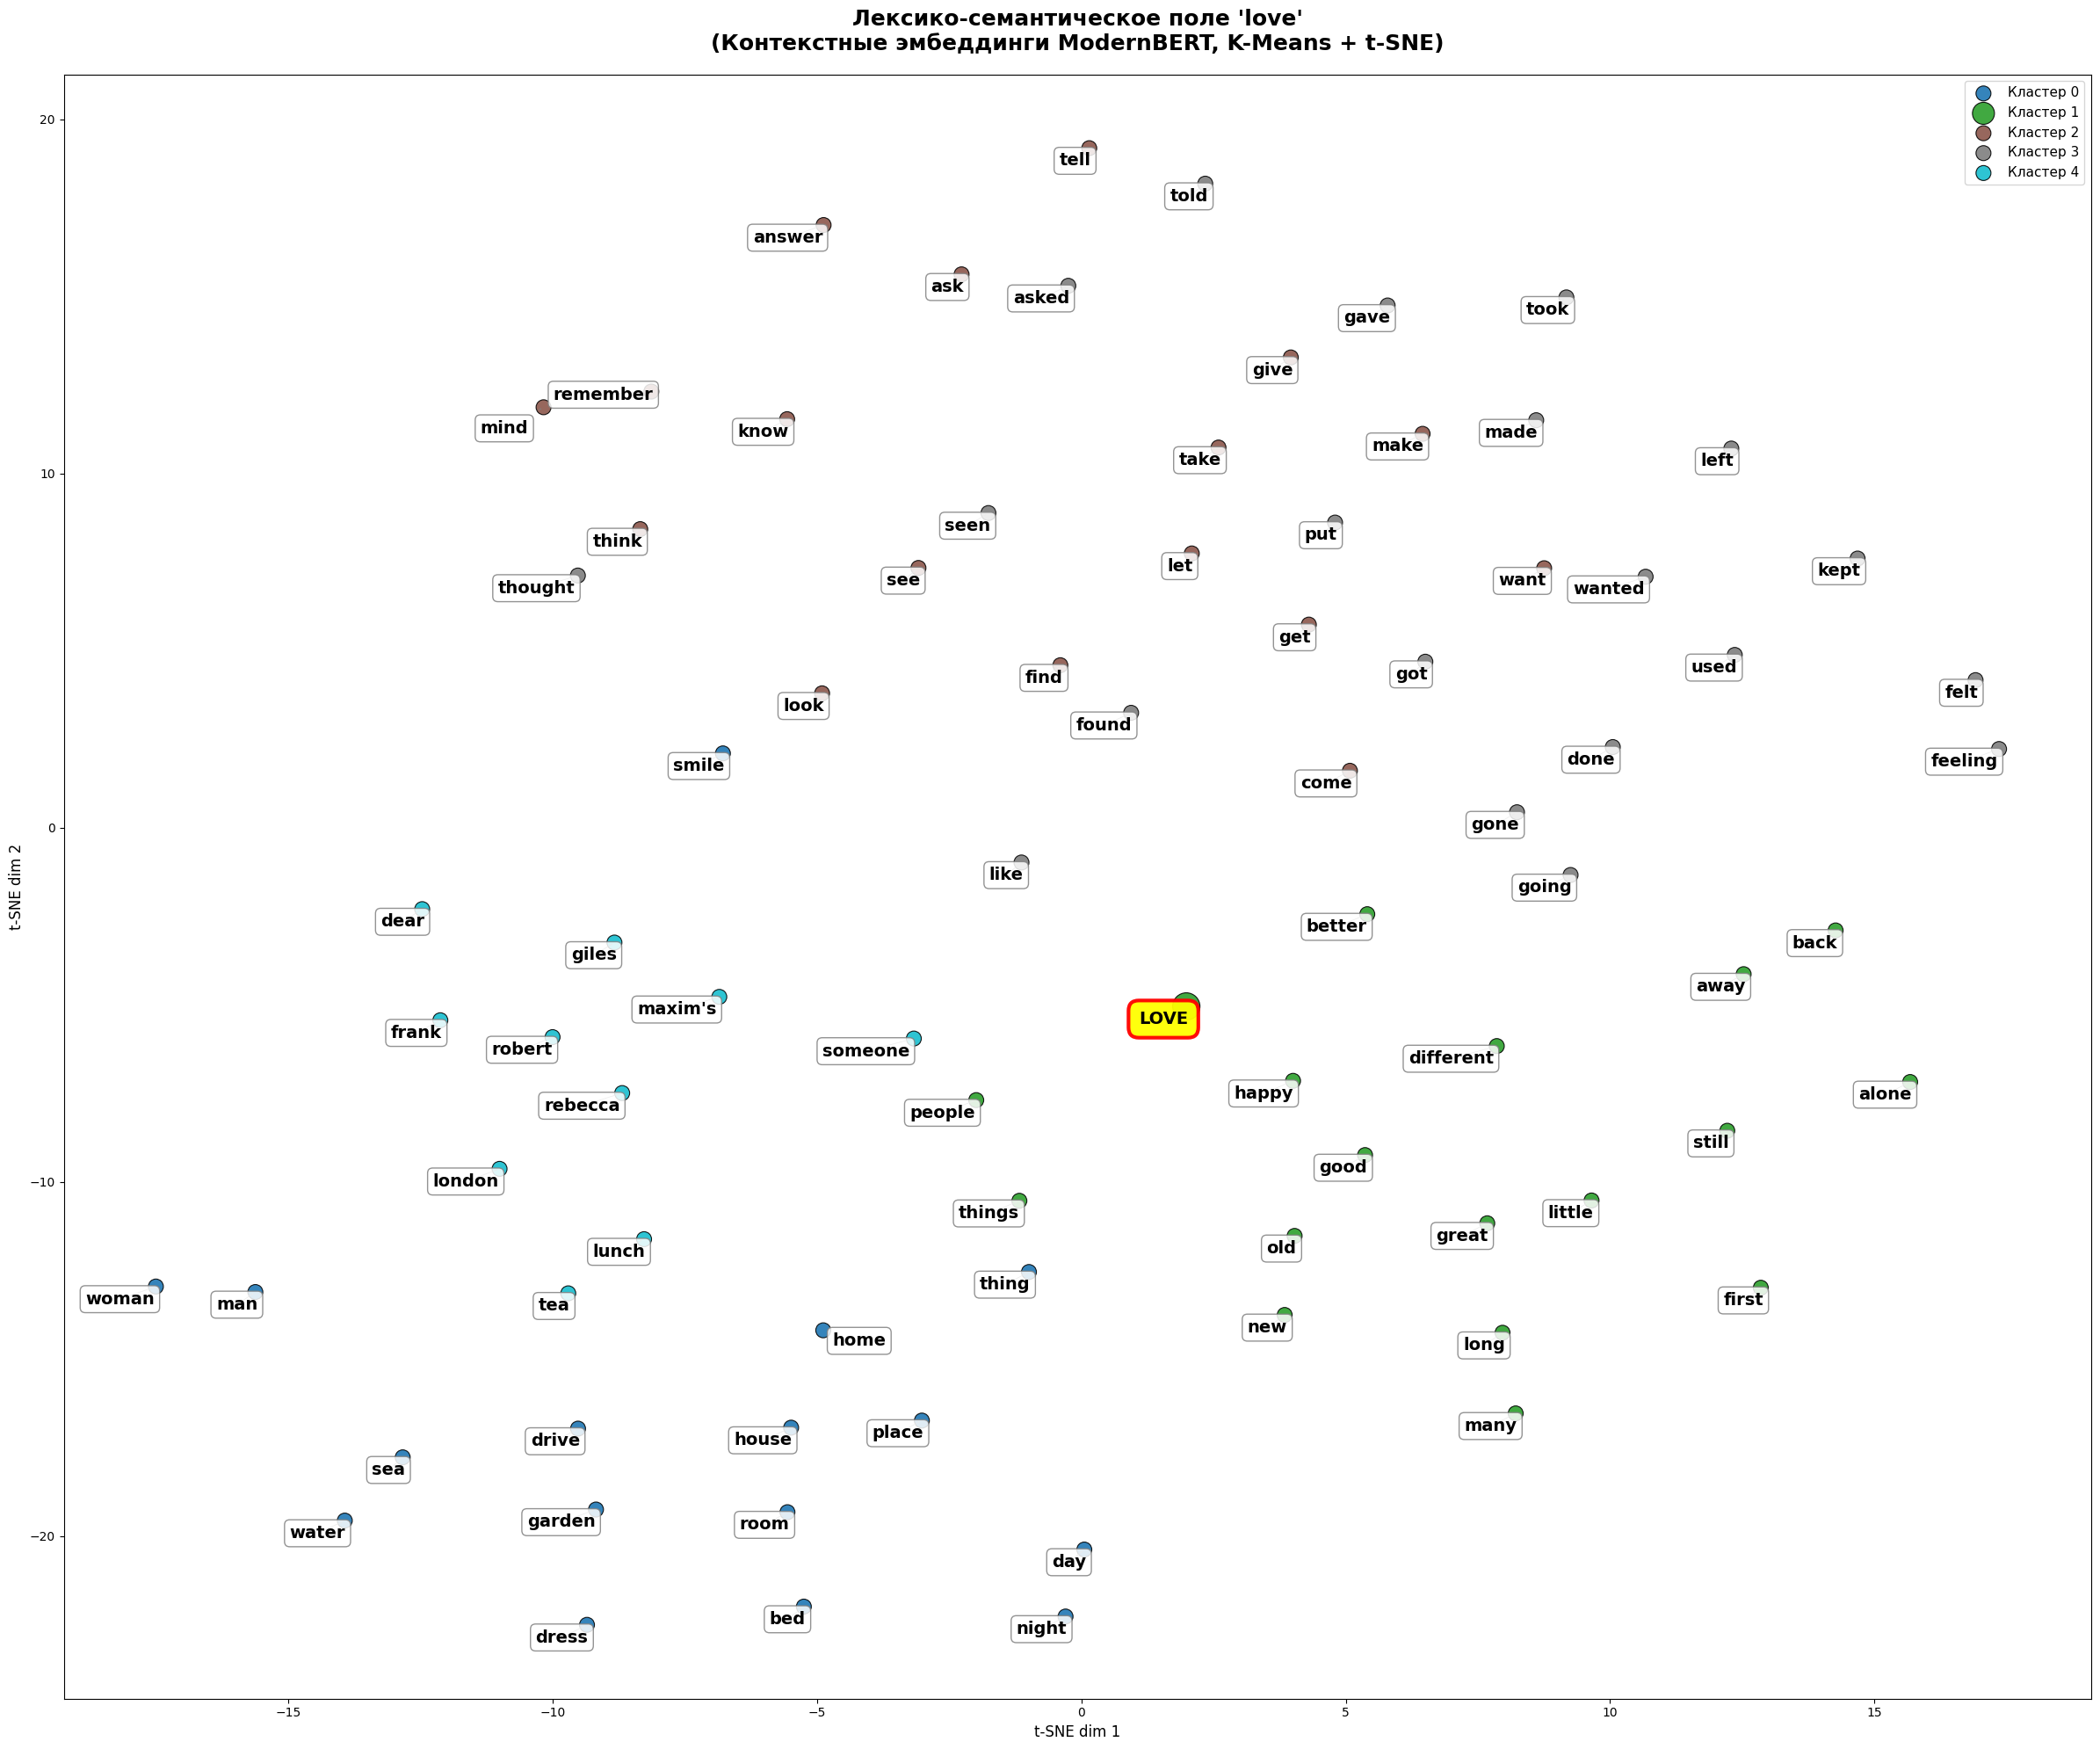


📈 Top-20 ассоциатов к 'love' (в контексте романа):

 1. happy           (similarity: 0.8419, cluster: 1)
 2. old             (similarity: 0.8298, cluster: 1)
 3. good            (similarity: 0.8266, cluster: 1)
 4. home            (similarity: 0.8258, cluster: 0)
 5. give            (similarity: 0.8246, cluster: 2)
 6. left            (similarity: 0.8236, cluster: 3)
 7. get             (similarity: 0.8227, cluster: 2)
 8. take            (similarity: 0.8220, cluster: 2)
 9. mind            (similarity: 0.8212, cluster: 2)
10. look            (similarity: 0.8197, cluster: 2)
11. new             (similarity: 0.8186, cluster: 1)
12. want            (similarity: 0.8184, cluster: 2)
13. felt            (similarity: 0.8161, cluster: 3)
14. got             (similarity: 0.8147, cluster: 3)
15. feeling         (similarity: 0.8142, cluster: 3)
16. see             (similarity: 0.8134, cluster: 2)
17. people          (similarity: 0.8134, cluster: 1)
18. wanted          (similarity: 0.8106, clust

In [ ]:
# по топ 200
concept = "love"

word_vectors, contexts, concept_vector = build_contextual_embeddings(
    concept,
    rebecca_sentences,
    tokenizer,
    model,
    device,
    max_contexts=500
)

if concept_vector is None:
    print(f"Ошибка: не удалось обработать слово '{concept}'")
else:
    word2vec_contextual = build_contextual_vocab_embeddings_top_w(
        concept,
        rebecca_sentences,
        tokenizer,
        model,
        device,
        top_k_words=200,
        max_contexts_per_word=50
    )

    all_words, vectors_2d, labels = visualize_contextual_semantic_field(
        concept,
        concept_vector,
        word2vec_contextual,
        contexts,
        topn=80
    )

    print("\n✅ Анализ завершен!")

Результаты метрик по моделированию с топ-200

```
Слов: 80, меток: 80, векторов: 80
Коэффициент силуэта: 0.0747
Индекс Дэвиса-Болдина: 2.7013

Средняя косинусная близость внутри кластеров:
  Кластер 0: 0.8274 (слов: 13)
  Кластер 1: 0.8477 (слов: 15)
  Кластер 2: 0.8256 (слов: 21)
  Кластер 3: 0.8752 (слов: 9)
  Кластер 4: 0.8353 (слов: 22)

Близость кластеров к 'love':
  Кластер 0 (day, place, man...): 0.8597
  Кластер 1 (left, felt, got...): 0.8592
  Кластер 2 (happy, good, old...): 0.8729
  Кластер 3 (dear, maxim's, london...): 0.8353
  Кластер 4 (give, get, take...): 0.8689
Состав кластеров:

Кластер 0 (13 слов):
  day, place, man, bed, room, thing, night, woman, house, dress, sea, garden, water

Кластер 1 (15 слов):
  left, felt, got, wanted, gave, asked, done, used, made, thought, told, kept, found, seen, took

Кластер 2 (21 слов):
  happy, good, old, home, new, feeling, people, gone, things, great, long, little, going, back, many, better, different, away, alone, someone, first

Кластер 3 (9 слов):
  dear, maxim's, london, rebecca, lunch, giles, robert, frank, tea

Кластер 4 (22 слов):
  give, get, take, want, mind, look, see, make, ask, remember, find, think, know, tell, come, put, smile, answer, let, say, like, understand

```

#### Моделирование по всему словарю

In [ ]:
# Проверка функции
vec = get_word_vector_in_context(
    "love",
    "She had always loved him.",
    tokenizer, model, device,
    pattern=r'\b(love|loves|loved|loving)\b',
    debug=True
)

Match: 'loved' [15:20]
Target token indices: [4]


In [ ]:
def get_wordnet_pos(word):
    """Простая эвристика для POS-тега для лемматизатора."""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_map = {'J': wordnet.ADJ, 'V': wordnet.VERB, 'R': wordnet.ADV}
    return tag_map.get(tag, wordnet.NOUN)

def lemmatize_word(word):
    return lemmatizer.lemmatize(word.lower(), get_wordnet_pos(word))

Подсчёт лемм...
Лемм-кандидатов: 2921 (уникальных слов в тексте: 6248)
Извлечение векторов...
0% 10% 20% 30% 40% 50% 60% 70% 80% 90% 100% 
Готово: 2760 лемм с векторами

📊 ПОСТРОЕНИЕ СЕМАНТИЧЕСКОГО ПОЛЯ (в контексте романа)

✓ Собрано 81 слов для визуализации
🔍 K-Means кластеризация в 768D пространстве...
✓ Инерция: 11.95, кластеров: 5
🎨 t-SNE редукция до 2D...


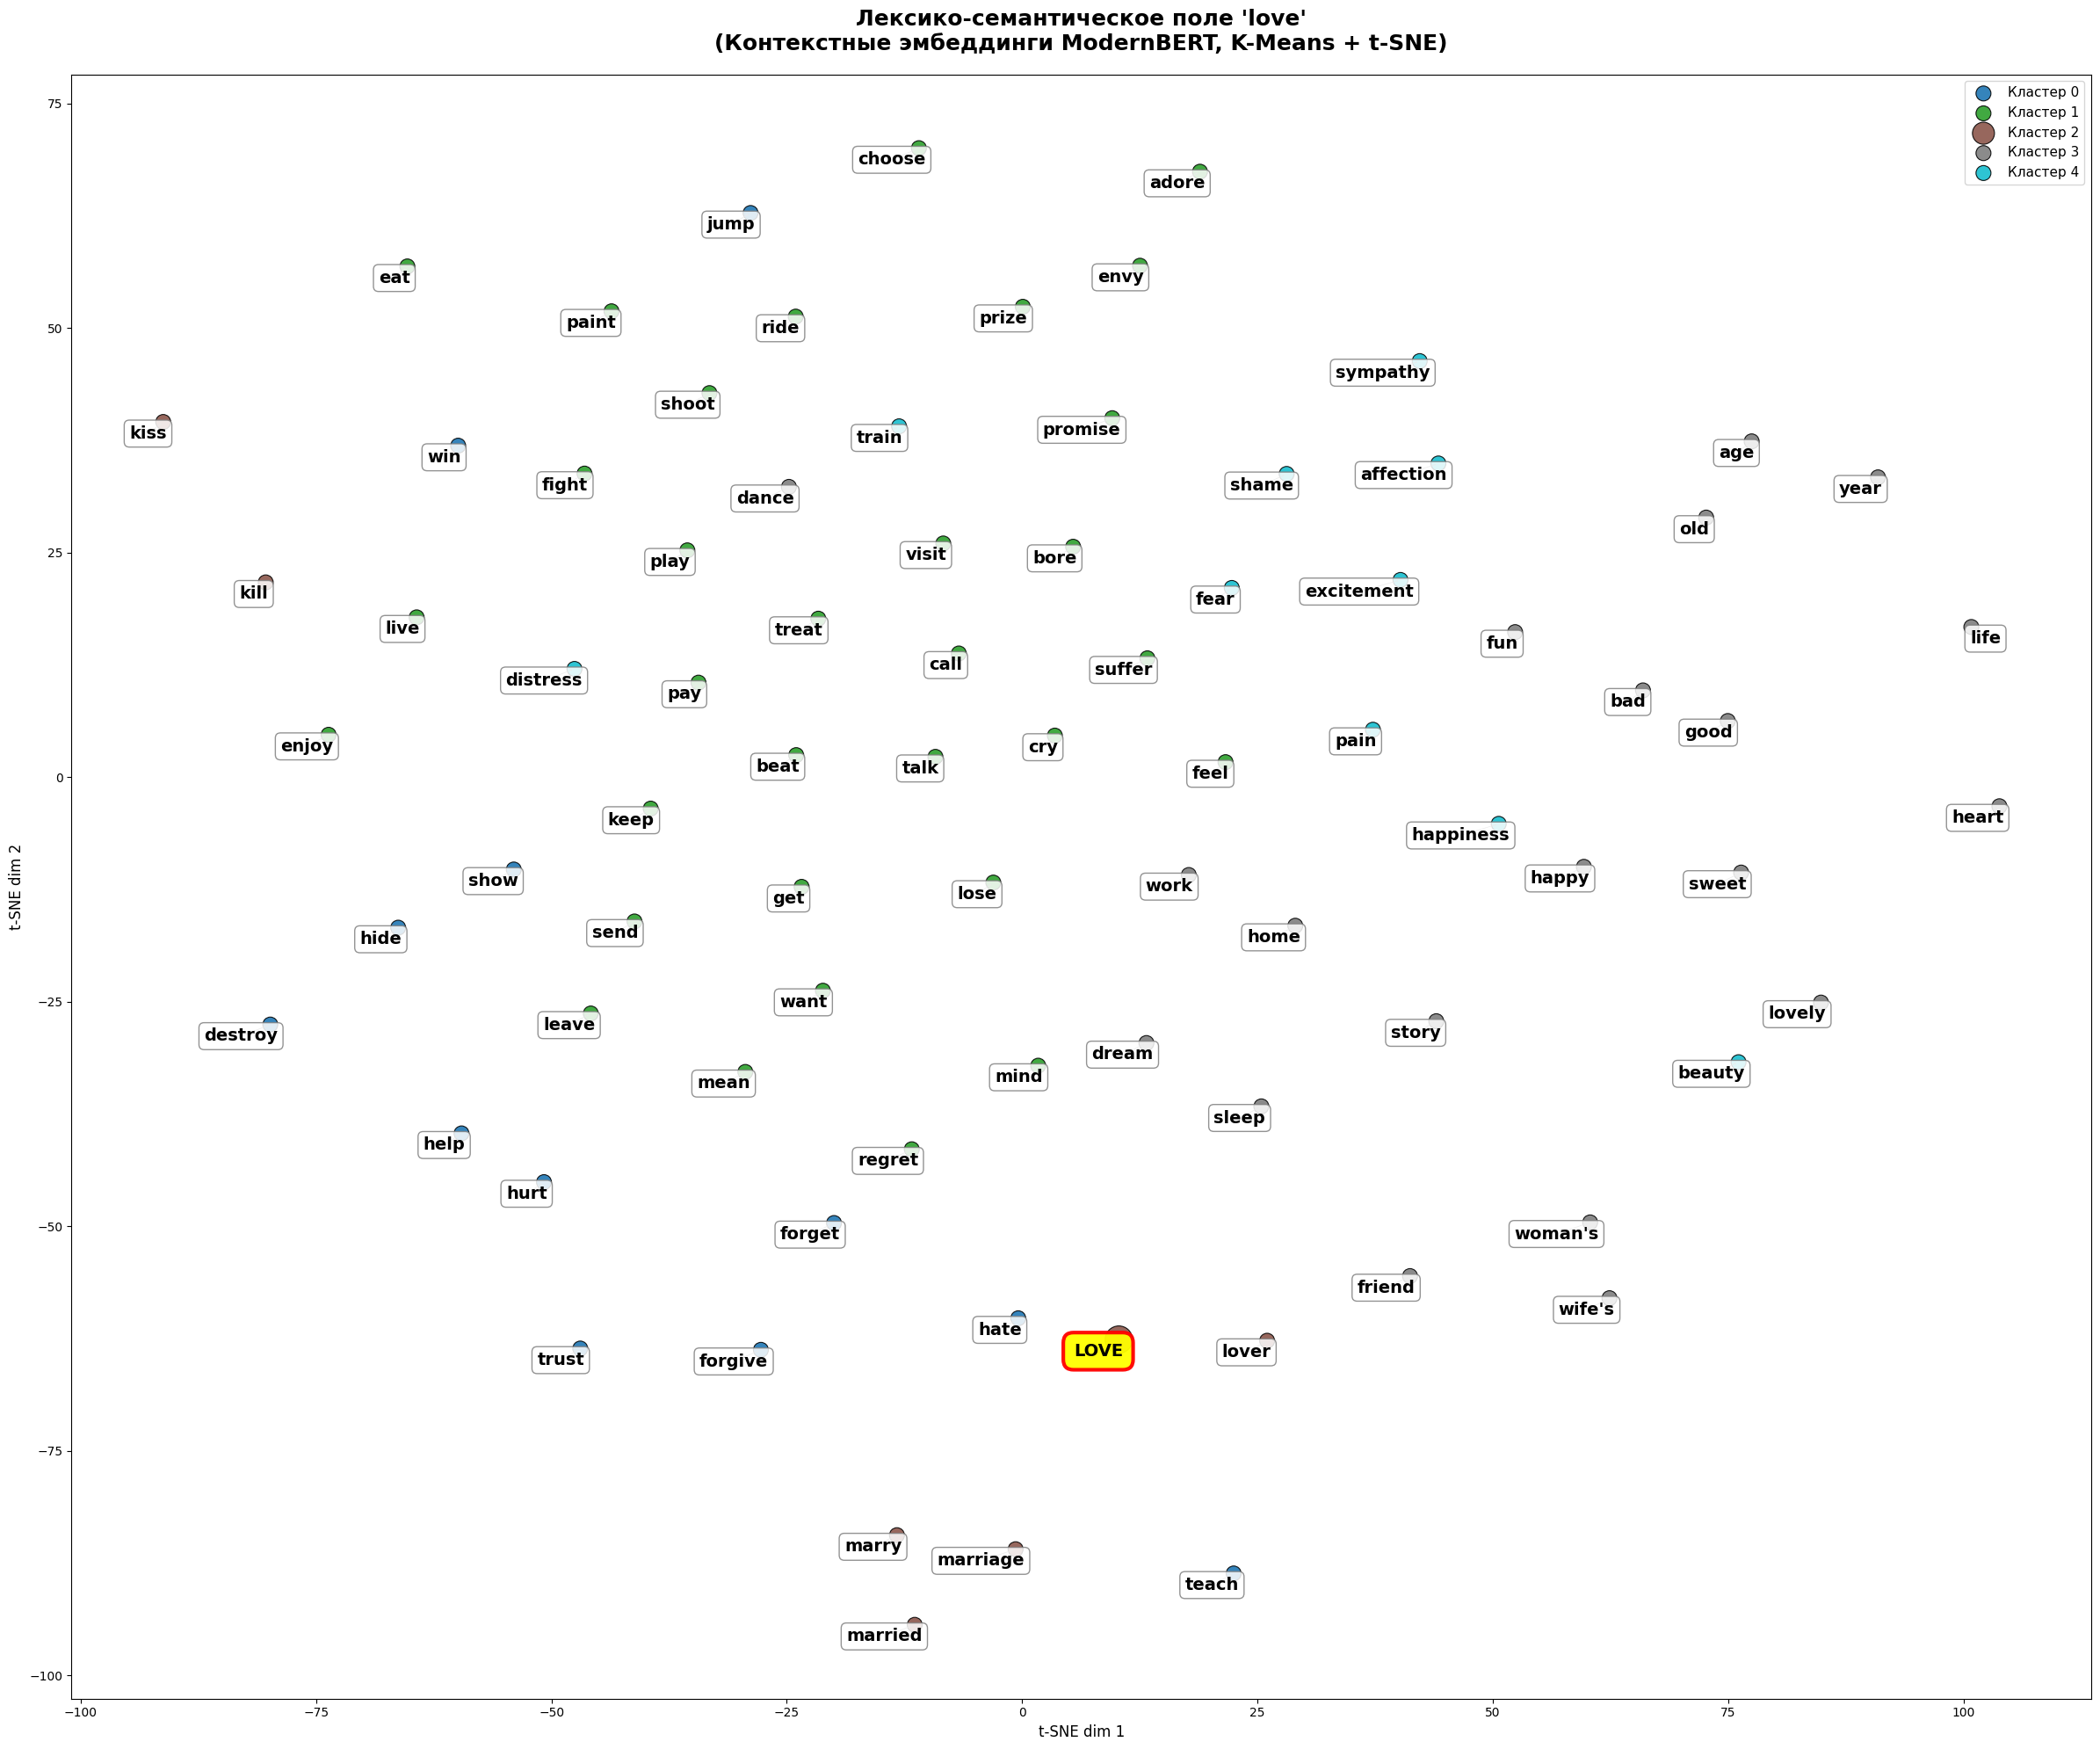


📈 Top-20 ассоциатов к 'love' (в контексте романа):

 1. hate            (similarity: 0.8754, cluster: 0)
 2. lover           (similarity: 0.8577, cluster: 2)
 3. marry           (similarity: 0.8567, cluster: 2)
 4. happiness       (similarity: 0.8462, cluster: 4)
 5. play            (similarity: 0.8454, cluster: 1)
 6. affection       (similarity: 0.8403, cluster: 4)
 7. fear            (similarity: 0.8371, cluster: 4)
 8. show            (similarity: 0.8364, cluster: 0)
 9. choose          (similarity: 0.8337, cluster: 1)
10. treat           (similarity: 0.8326, cluster: 1)
11. hurt            (similarity: 0.8320, cluster: 0)
12. work            (similarity: 0.8284, cluster: 3)
13. regret          (similarity: 0.8283, cluster: 1)
14. kill            (similarity: 0.8268, cluster: 2)
15. happy           (similarity: 0.8262, cluster: 3)
16. marriage        (similarity: 0.8241, cluster: 2)
17. feel            (similarity: 0.8232, cluster: 1)
18. leave           (similarity: 0.8226, clust

ValueError: not enough values to unpack (expected 5, got 3)

In [ ]:
word2vec_contextual = build_contextual_vocab_embeddings_lemmatized(
    concept_word="love",
    all_sentences=rebecca_sentences,
    tokenizer=tokenizer,
    model=model,
    device=device,
    min_freq=3,        # слово встречается хотя бы 3 раза (по всем формам)
    max_words=None,    # без ограничений → весь словарь
    max_contexts_per_word=30,
)


📊 ПОСТРОЕНИЕ СЕМАНТИЧЕСКОГО ПОЛЯ (в контексте романа)

✓ Собрано 81 слов для визуализации
🔍 K-Means кластеризация в 768D пространстве...
✓ Инерция: 11.95, кластеров: 5
🎨 t-SNE редукция до 2D...


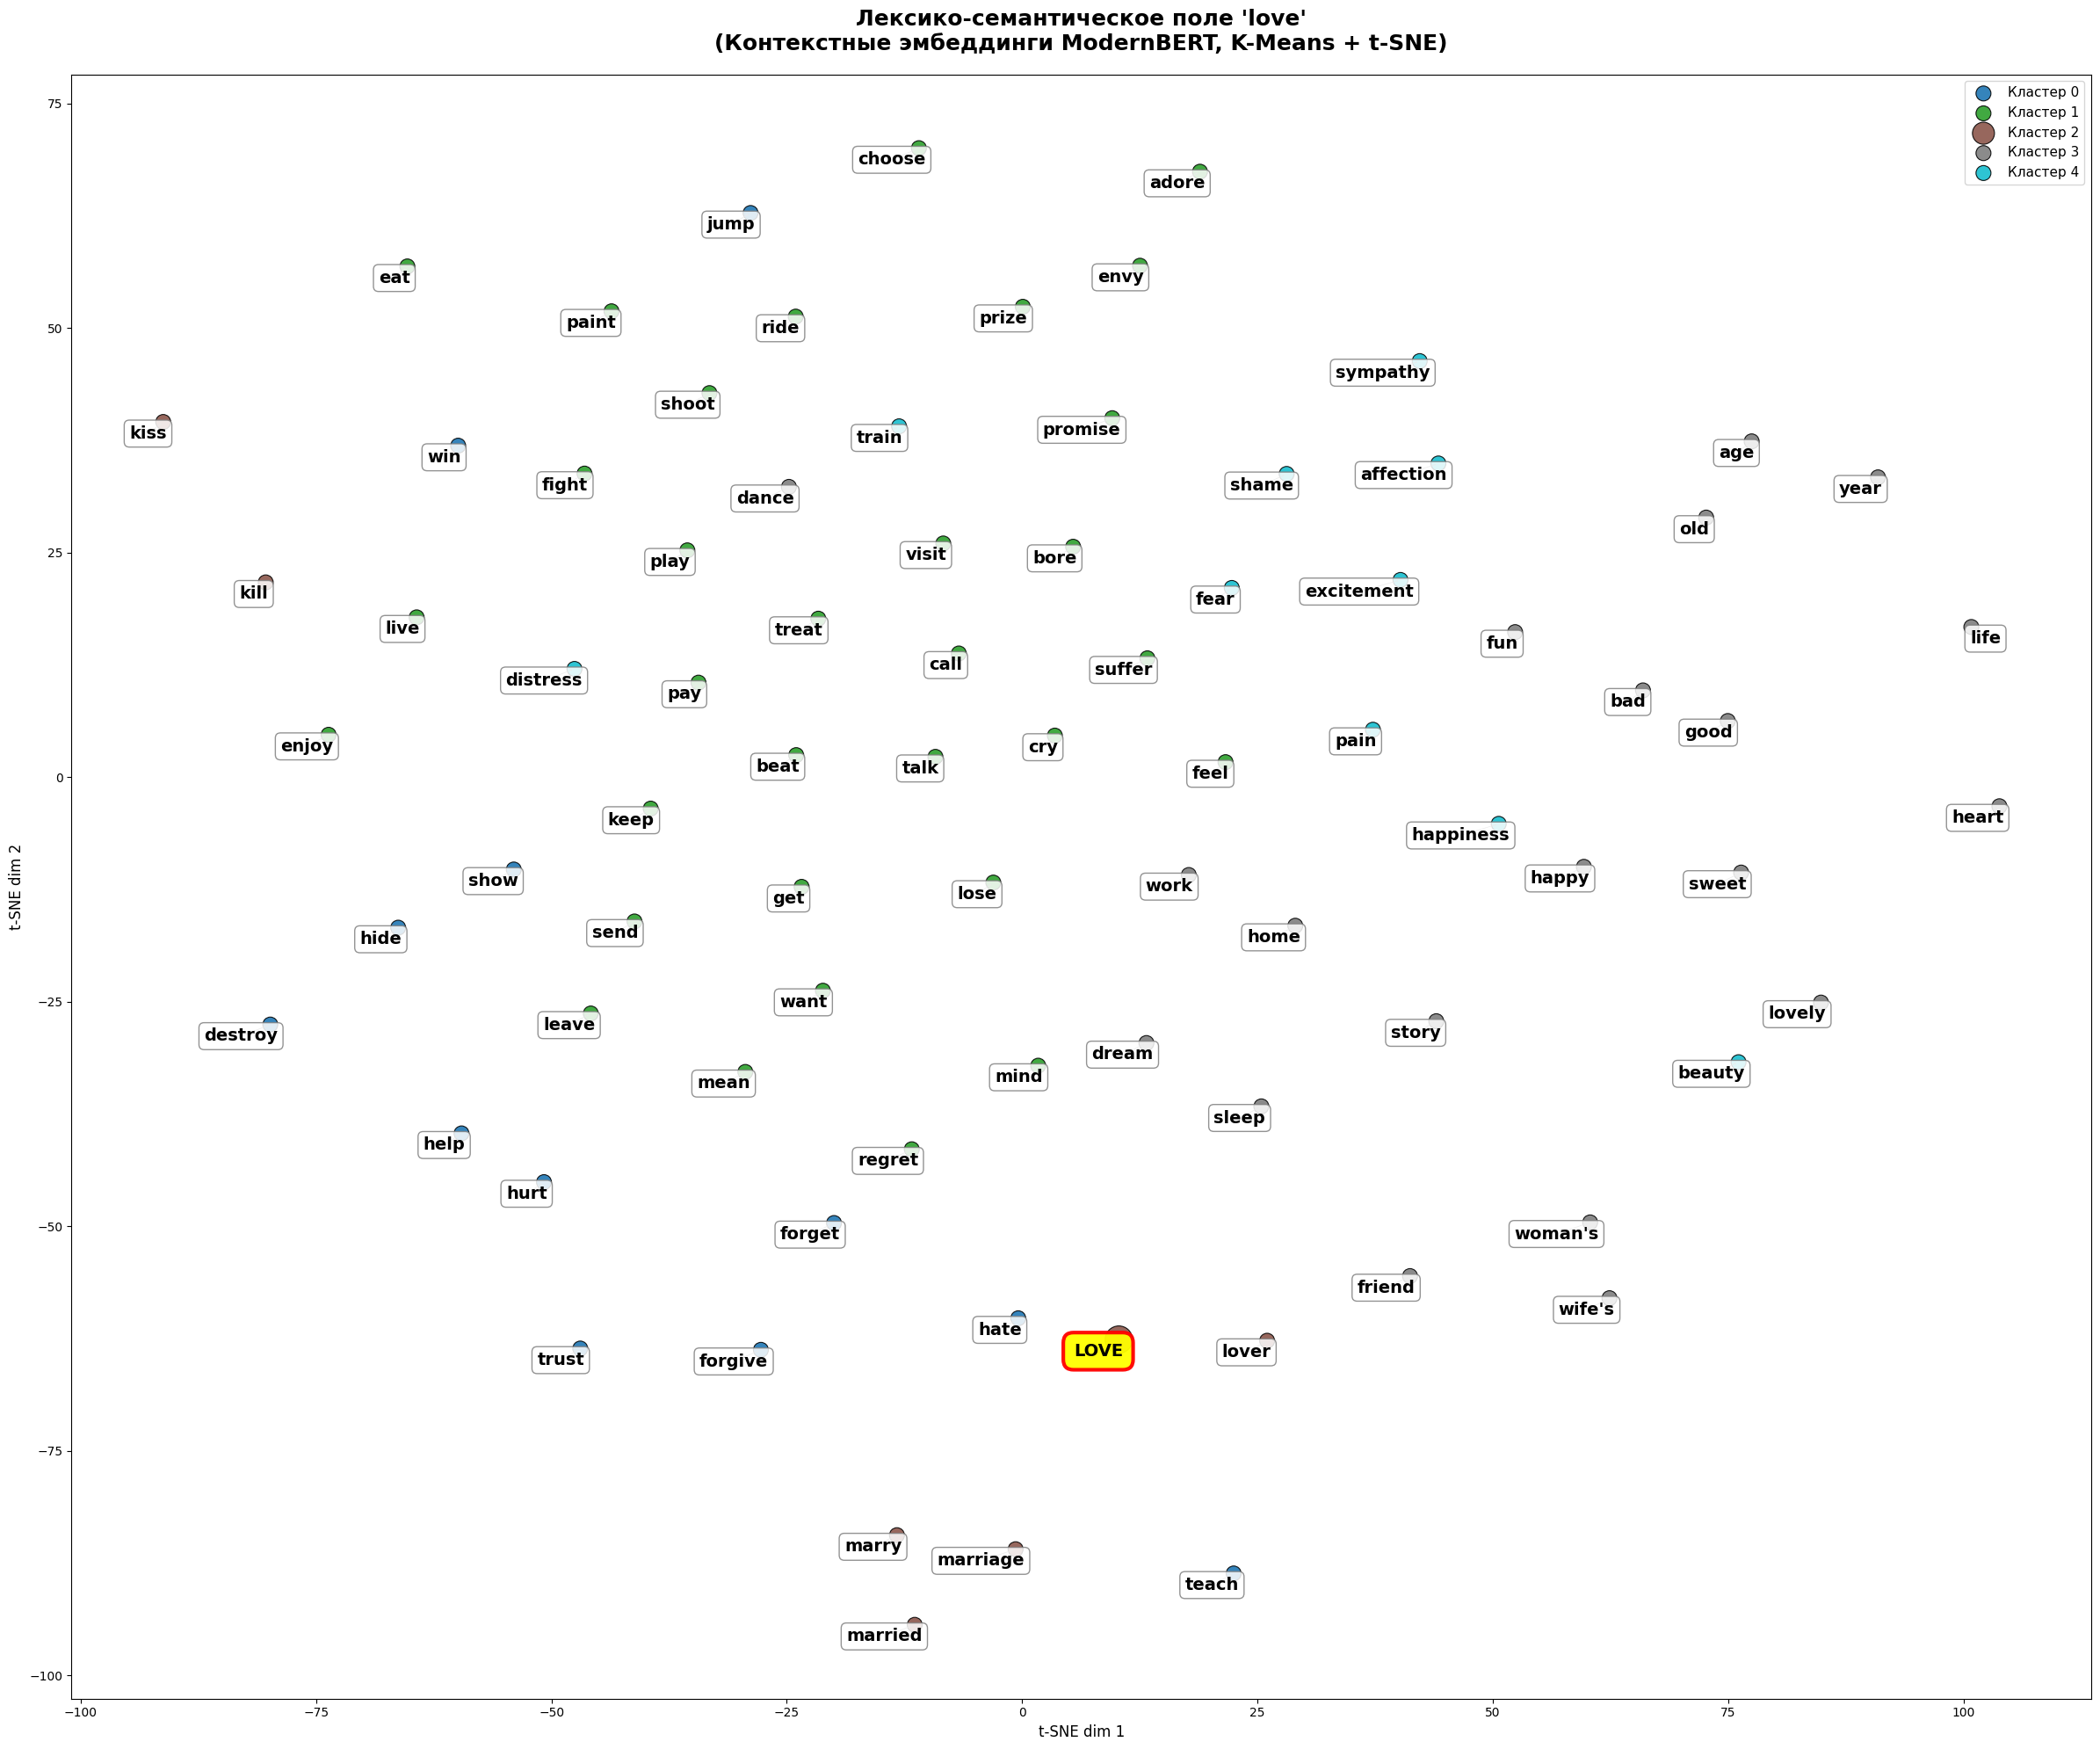


📈 Top-20 ассоциатов к 'love' (в контексте романа):

 1. hate            (similarity: 0.8754, cluster: 0)
 2. lover           (similarity: 0.8577, cluster: 2)
 3. marry           (similarity: 0.8567, cluster: 2)
 4. happiness       (similarity: 0.8462, cluster: 4)
 5. play            (similarity: 0.8454, cluster: 1)
 6. affection       (similarity: 0.8403, cluster: 4)
 7. fear            (similarity: 0.8371, cluster: 4)
 8. show            (similarity: 0.8364, cluster: 0)
 9. choose          (similarity: 0.8337, cluster: 1)
10. treat           (similarity: 0.8326, cluster: 1)
11. hurt            (similarity: 0.8320, cluster: 0)
12. work            (similarity: 0.8284, cluster: 3)
13. regret          (similarity: 0.8283, cluster: 1)
14. kill            (similarity: 0.8268, cluster: 2)
15. happy           (similarity: 0.8262, cluster: 3)
16. marriage        (similarity: 0.8241, cluster: 2)
17. feel            (similarity: 0.8232, cluster: 1)
18. leave           (similarity: 0.8226, clust

In [ ]:
all_words, vectors_2d, labels = visualize_contextual_semantic_field(
    "love", concept_vector, word2vec_contextual, contexts, topn=80
)

Метрики после лемматизации и по всему тексту моделирование

```
Слов: 80, меток: 80, векторов: 80
Коэффициент силуэта: 0.0265
Индекс Дэвиса-Болдина: 3.4462

Средняя косинусная близость внутри кластеров:
  Кластер 0: 0.8343 (слов: 12)
  Кластер 1: 0.8476 (слов: 32)
  Кластер 2: 0.8447 (слов: 6)
  Кластер 3: 0.8301 (слов: 20)
  Кластер 4: 0.8641 (слов: 10)

Близость кластеров к 'love':
  Кластер 0 (hate, show, hurt...): 0.8934
  Кластер 1 (play, choose, treat...): 0.8858
  Кластер 2 (lover, marry, kill...): 0.8911
  Кластер 3 (work, happy, dance...): 0.8900
  Кластер 4 (happiness, affection, fear...): 0.8772
  Состав кластеров:

Кластер 0 (12 слов):
  hate, show, hurt, hide, forget, help, forgive, jump, teach, win, destroy, trust

Кластер 1 (32 слов):
  play, choose, treat, regret, feel, leave, pay, fight, call, get, cry, suffer, adore, mean, live, mind, shoot, want, lose, envy, keep, send, prize, talk, eat, bore, visit, paint, ride, beat, enjoy, promise

Кластер 2 (6 слов):
  lover, marry, kill, marriage, kiss, married

Кластер 3 (20 слов):
  work, happy, dance, home, friend, dream, fun, old, heart, good, sweet, wife's, bad, age, life, year, lovely, sleep, story, woman's

Кластер 4 (10 слов):
  happiness, affection, fear, pain, beauty, train, distress, sympathy, excitement, shame
```

### Метрики и значения




In [ ]:
# Собираем матрицу векторов топ-80 слов
filtered = [(w, l) for w, l in zip(all_words, labels) if w in word2vec_contextual]
top_words_list = [w for w, l in filtered]
top_labels_arr = np.array([l for w, l in filtered])
top_vectors = np.array([word2vec_contextual[w] for w in top_words_list])

print(f"Слов: {len(top_words_list)}, меток: {len(top_labels_arr)}, векторов: {len(top_vectors)}")

# 1. Silhouette Score (чем ближе к 1 — тем лучше кластеры)
sil = silhouette_score(top_vectors, top_labels_arr)
print(f"Коэффициент силуэта: {sil:.4f}")

# 2. Davies-Bouldin Index (чем меньше — тем лучше)
db = davies_bouldin_score(top_vectors, top_labels_arr)
print(f"Индекс Дэвиса-Болдина: {db:.4f}")

# 3. Средняя косинусная близость внутри каждого кластера
print("\nСредняя косинусная близость внутри кластеров:")
for cluster_id in sorted(set(top_labels_arr)):
    cluster_vectors = top_vectors[np.array(top_labels_arr) == cluster_id]
    if len(cluster_vectors) > 1:
        sim_matrix = cosine_similarity(cluster_vectors)
        # Берём только верхний треугольник без диагонали
        upper = sim_matrix[np.triu_indices(len(sim_matrix), k=1)]
        print(f"  Кластер {cluster_id}: {upper.mean():.4f} (слов: {len(cluster_vectors)})")

# 4. Косинусная близость каждого кластера к вектору 'love'
print("\nБлизость кластеров к 'love':")
for cluster_id in sorted(set(top_labels_arr)):
    cluster_vectors = top_vectors[top_labels_arr == cluster_id]
    centroid = cluster_vectors.mean(axis=0)
    sim = cosine_similarity([concept_vector], [centroid])[0][0]
    cluster_words = [w for w, l in zip(top_words_list, top_labels_arr) if l == cluster_id]
    print(f"  Кластер {cluster_id} ({', '.join(cluster_words[:3])}...): {sim:.4f}")


Слов: 80, меток: 80, векторов: 80
Коэффициент силуэта: 0.0265
Индекс Дэвиса-Болдина: 3.4462

Средняя косинусная близость внутри кластеров:
  Кластер 0: 0.8343 (слов: 12)
  Кластер 1: 0.8476 (слов: 32)
  Кластер 2: 0.8447 (слов: 6)
  Кластер 3: 0.8301 (слов: 20)
  Кластер 4: 0.8641 (слов: 10)

Близость кластеров к 'love':
  Кластер 0 (hate, show, hurt...): 0.8934
  Кластер 1 (play, choose, treat...): 0.8858
  Кластер 2 (lover, marry, kill...): 0.8911
  Кластер 3 (work, happy, dance...): 0.8900
  Кластер 4 (happiness, affection, fear...): 0.8772


Состав кластеров:

In [ ]:
print("Состав кластеров:\n")
for cluster_id in sorted(set(top_labels_arr)):
    cluster_words = [w for w, l in zip(top_words_list, top_labels_arr) if l == cluster_id]
    print(f"Кластер {cluster_id} ({len(cluster_words)} слов):")
    print(f"  {', '.join(cluster_words)}")
    print()

Состав кластеров:

Кластер 0 (12 слов):
  hate, show, hurt, hide, forget, help, forgive, jump, teach, win, destroy, trust

Кластер 1 (32 слов):
  play, choose, treat, regret, feel, leave, pay, fight, call, get, cry, suffer, adore, mean, live, mind, shoot, want, lose, envy, keep, send, prize, talk, eat, bore, visit, paint, ride, beat, enjoy, promise

Кластер 2 (6 слов):
  lover, marry, kill, marriage, kiss, married

Кластер 3 (20 слов):
  work, happy, dance, home, friend, dream, fun, old, heart, good, sweet, wife's, bad, age, life, year, lovely, sleep, story, woman's

Кластер 4 (10 слов):
  happiness, affection, fear, pain, beauty, train, distress, sympathy, excitement, shame

